# Generate ROC AUC plot demonstrating improvement in `performance` after QC and compare coSMicQC and PyOD ECOD

This code is derived from the `cellpainting_predicts_cardiac_fibrosis` repository.

In [1]:
import pathlib
import sys

import joblib
import numpy as np
import pandas as pd
from joblib import load
from plotnine import (
    aes,
    element_line,
    element_text,
    geom_histogram,
    geom_line,
    geom_vline,
    ggplot,
    labs,
    scale_color_manual,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

sys.path.append("../figure_3")
from figure3_utils import bootstrap_roc_auc, get_X_y_data


In [2]:
figure_path = pathlib.Path("./figures")
# make directory if it doesn't already exist
figure_path.mkdir(exist_ok=True)


## Load in label encoder

In [3]:
# load in label encoder
le = load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/encoder_results/label_encoder_log_reg_fs_plate_4.joblib"
    )
)


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


## Load in no-QC model and dataset

In [4]:
# Load the trained model
no_QC_model = joblib.load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/models/no_QC_models/log_reg_fs_plate_4_final_downsample_no_QC.joblib"
    )
)

# Load the feature-selected QC plate 4 (ensure it includes both features and labels)
plate_4_no_QC = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_feature_selected_no_QC.parquet"
    )
)

# Filter the test_data to only include rows where:
# - Metadata_heart_number == 7 and Metadata_treatment == "DMSO"
# - OR Metadata_heart_number == 29
healthy_heart_number = 7
failing_heart_number = 29
holdout_no_QC_data = plate_4_no_QC[
    (
        (plate_4_no_QC["Metadata_heart_number"] == healthy_heart_number)
        & (plate_4_no_QC["Metadata_treatment"] == "DMSO")
    )
    | (plate_4_no_QC["Metadata_heart_number"] == failing_heart_number)
]
print(f"Holdout no QC data shape: {holdout_no_QC_data.shape}")

# Load in X and y data from dataset
X, y = get_X_y_data(df=holdout_no_QC_data, label="Metadata_cell_type")

# Assign y classes to correct binary using label encoder results
y_binary_no_QC = le.transform(y)

# Predict probabilities for the positive class
y_probs_modelNoQC = no_QC_model.predict_proba(X)[:, 1]


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Holdout no QC data shape: (3998, 667)


## Load in coSMicQC model and dataset

In [5]:
# Load the trained model
QC_model = joblib.load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/models/log_reg_fs_plate_4_final_downsample.joblib"
    )
)

# Load the feature-selected QC plate 4 (ensure it includes both features and labels)
plate_4_QC = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_feature_selected.parquet"
    )
)

# Filter the test_data to only include rows where:
# - Metadata_heart_number == 7 and Metadata_treatment == "DMSO"
# - OR Metadata_heart_number == 29
holdout_QC_data = plate_4_QC[
    (
        (plate_4_QC["Metadata_heart_number"] == healthy_heart_number)
        & (plate_4_QC["Metadata_treatment"] == "DMSO")
    )
    | (plate_4_QC["Metadata_heart_number"] == failing_heart_number)
]
print(f"Holdout QC data shape: {holdout_QC_data.shape}")

# Load in X and y data from dataset
X, y = get_X_y_data(df=holdout_QC_data, label="Metadata_cell_type")

# Assign y classes to correct binary using label encoder results
y_binary_QC = le.transform(y)

# Predict probabilities for the positive class
y_probs_modelQC = QC_model.predict_proba(X)[:, 1]


Holdout QC data shape: (3008, 644)


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


## Load in ECOD model and dataset

In [6]:
# Load the trained model
ECOD_model = joblib.load(
    pathlib.Path(
        "./models/log_reg_fs_ecod_final_downsample.joblib"
    )
)

# Load the feature-selected QC plate 4 (ensure it includes both features and labels)
plate_4_ECOD = pd.read_parquet(
    pathlib.Path(
        "./models/idc_normalized_feature_selected.parquet"
    )
)

# Filter the test_data to only include rows where:
# - Metadata_heart_number == 7 and Metadata_treatment == "DMSO"
# - OR Metadata_heart_number == 29
holdout_ECOD_data = plate_4_ECOD[
    (
        (plate_4_ECOD["Metadata_heart_number"] == healthy_heart_number)
        & (plate_4_ECOD["Metadata_treatment"] == "DMSO")
    )
    | (plate_4_ECOD["Metadata_heart_number"] == failing_heart_number)
]
print(f"Holdout ECOD data shape: {holdout_ECOD_data.shape}")

# Load in X and y data from dataset
X, y = get_X_y_data(df=holdout_ECOD_data, label="Metadata_cell_type")

# Assign y classes to correct binary using label encoder results
y_binary_ECOD = le.transform(y)

# Predict probabilities for the positive class
y_probs_modelECOD = ECOD_model.predict_proba(X)[:, 1]


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Holdout ECOD data shape: (2807, 720)


## Calculate ROC AUC score by applying the model to their respective dataset

e.g., QC model applyied on QC heldout wells dataset and vice versa.

In [7]:
# Calculate ROC AUC
aucNoQC = roc_auc_score(y_binary_no_QC, y_probs_modelNoQC)
aucQC = roc_auc_score(y_binary_QC, y_probs_modelQC)
aucECOD = roc_auc_score(y_binary_ECOD, y_probs_modelECOD)

print(f"AUC Model 1: {aucNoQC}")
print(f"AUC Model 2: {aucQC}")
print(f"AUC Model 3: {aucECOD}")


AUC Model 1: 0.9053365172047568
AUC Model 2: 0.9288569897636957
AUC Model 3: 0.9292461315493828


In [8]:
print(f"Number of cells in holdout no-QC dataset: {holdout_no_QC_data.shape[0]}")
print(f"Number of cells in holdout QC dataset: {holdout_QC_data.shape[0]}")
print(f"Number of cells in holdout ECOD dataset: {holdout_ECOD_data.shape[0]}")


Number of cells in holdout no-QC dataset: 3998
Number of cells in holdout QC dataset: 3008
Number of cells in holdout ECOD dataset: 2807


## Apply bootstrapping method to evaluate performance between models

We bootstrap using 20% of the no-QC dataset (without replacement), and match
that same absolute number of cells when bootstrapping the coSMicQC and ECOD
datasets, so all three models are compared using equally sized bootstrap
samples rather than each being sampled at 20% of its own (differently
sized) dataset. We use 1000 iterations for the bootstrapping method.
T-Test is used to see if the distributions are significantly different.

In [9]:
# Use 20% of the no-QC dataset as the fixed bootstrap sample size, and apply
# that same sample size to the QC and ECOD datasets so all three models are
# compared using equally sized bootstrap samples.
bootstrap_sample_size = int(0.20 * len(y_binary_no_QC))
print(f"Bootstrap sample size (cells per iteration): {bootstrap_sample_size}")

# No QC model
scores_model1 = bootstrap_roc_auc(
    y_binary_no_QC, y_probs_modelNoQC, n_samples=bootstrap_sample_size
)

# QC model
scores_model2 = bootstrap_roc_auc(
    y_binary_QC, y_probs_modelQC, n_samples=bootstrap_sample_size
)

# ECOD model
scores_model3 = bootstrap_roc_auc(
    y_binary_ECOD, y_probs_modelECOD, n_samples=bootstrap_sample_size
)

# Compare distributions (means)
mean1 = scores_model1.mean()
mean2 = scores_model2.mean()
mean3 = scores_model3.mean()

# Confidence intervals for each model
ci1 = np.percentile(scores_model1, [2.5, 97.5])
ci2 = np.percentile(scores_model2, [2.5, 97.5])
ci3 = np.percentile(scores_model3, [2.5, 97.5])

# ---- Bootstrap difference distribution ----
diff_scores = scores_model2 - scores_model1
mean_diff = diff_scores.mean()
ci_diff = np.percentile(diff_scores, [2.5, 97.5])

# Probability QC > no QC (bootstrap superiority probability)
prob_better = np.mean(scores_model2 > scores_model1[:, None])

# Reporting
print(f"Model 1 AUC: {mean1:.3f} (95% CI: {ci1[0]:.3f} - {ci1[1]:.3f})")
print(f"Model 2 AUC: {mean2:.3f} (95% CI: {ci2[0]:.3f} - {ci2[1]:.3f})")
print(f"Model 3 AUC: {mean3:.3f} (95% CI: {ci3[0]:.3f} - {ci3[1]:.3f})")
print(
    f"Mean AUC difference (QC - no QC): {mean_diff:.3f} "
    f"(95% CI: {ci_diff[0]:.3f} - {ci_diff[1]:.3f})"
)
print(f"P(QC > no QC): {prob_better:.3f}")


Bootstrap sample size (cells per iteration): 799
Model 1 AUC: 0.905 (95% CI: 0.885 - 0.923)
Model 2 AUC: 0.929 (95% CI: 0.912 - 0.944)
Model 3 AUC: 0.929 (95% CI: 0.911 - 0.945)
Mean AUC difference (QC - no QC): 0.024 (95% CI: -0.000 - 0.049)
P(QC > no QC): 0.966


In [10]:
# ---- Bootstrap difference distribution ----
diff_scores_QC = scores_model2 - scores_model3
mean_diff_QC = diff_scores_QC.mean()
ci_diff_QC = np.percentile(diff_scores_QC, [2.5, 97.5])
print(
    f"Mean AUC difference (coSMicQC - ECOD): {mean_diff_QC:.3f} "
    f"(95% CI: {ci_diff_QC[0]:.3f} - {ci_diff_QC[1]:.3f})"
)
# Probability coSMicQC > ECOD (bootstrap superiority probability)
prob_better = np.mean(scores_model2 > scores_model3[:, None])
print(f"P(coSMicQC > ECOD): {prob_better:.3f}")
print(f"P(coSMicQC < ECOD): {1 - prob_better:.3f}")


Mean AUC difference (coSMicQC - ECOD): -0.000 (95% CI: -0.025 - 0.023)
P(coSMicQC > ECOD): 0.486
P(coSMicQC < ECOD): 0.514


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 7 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/bootstrap_ROC_AUC_QC_versus_no_QC.png


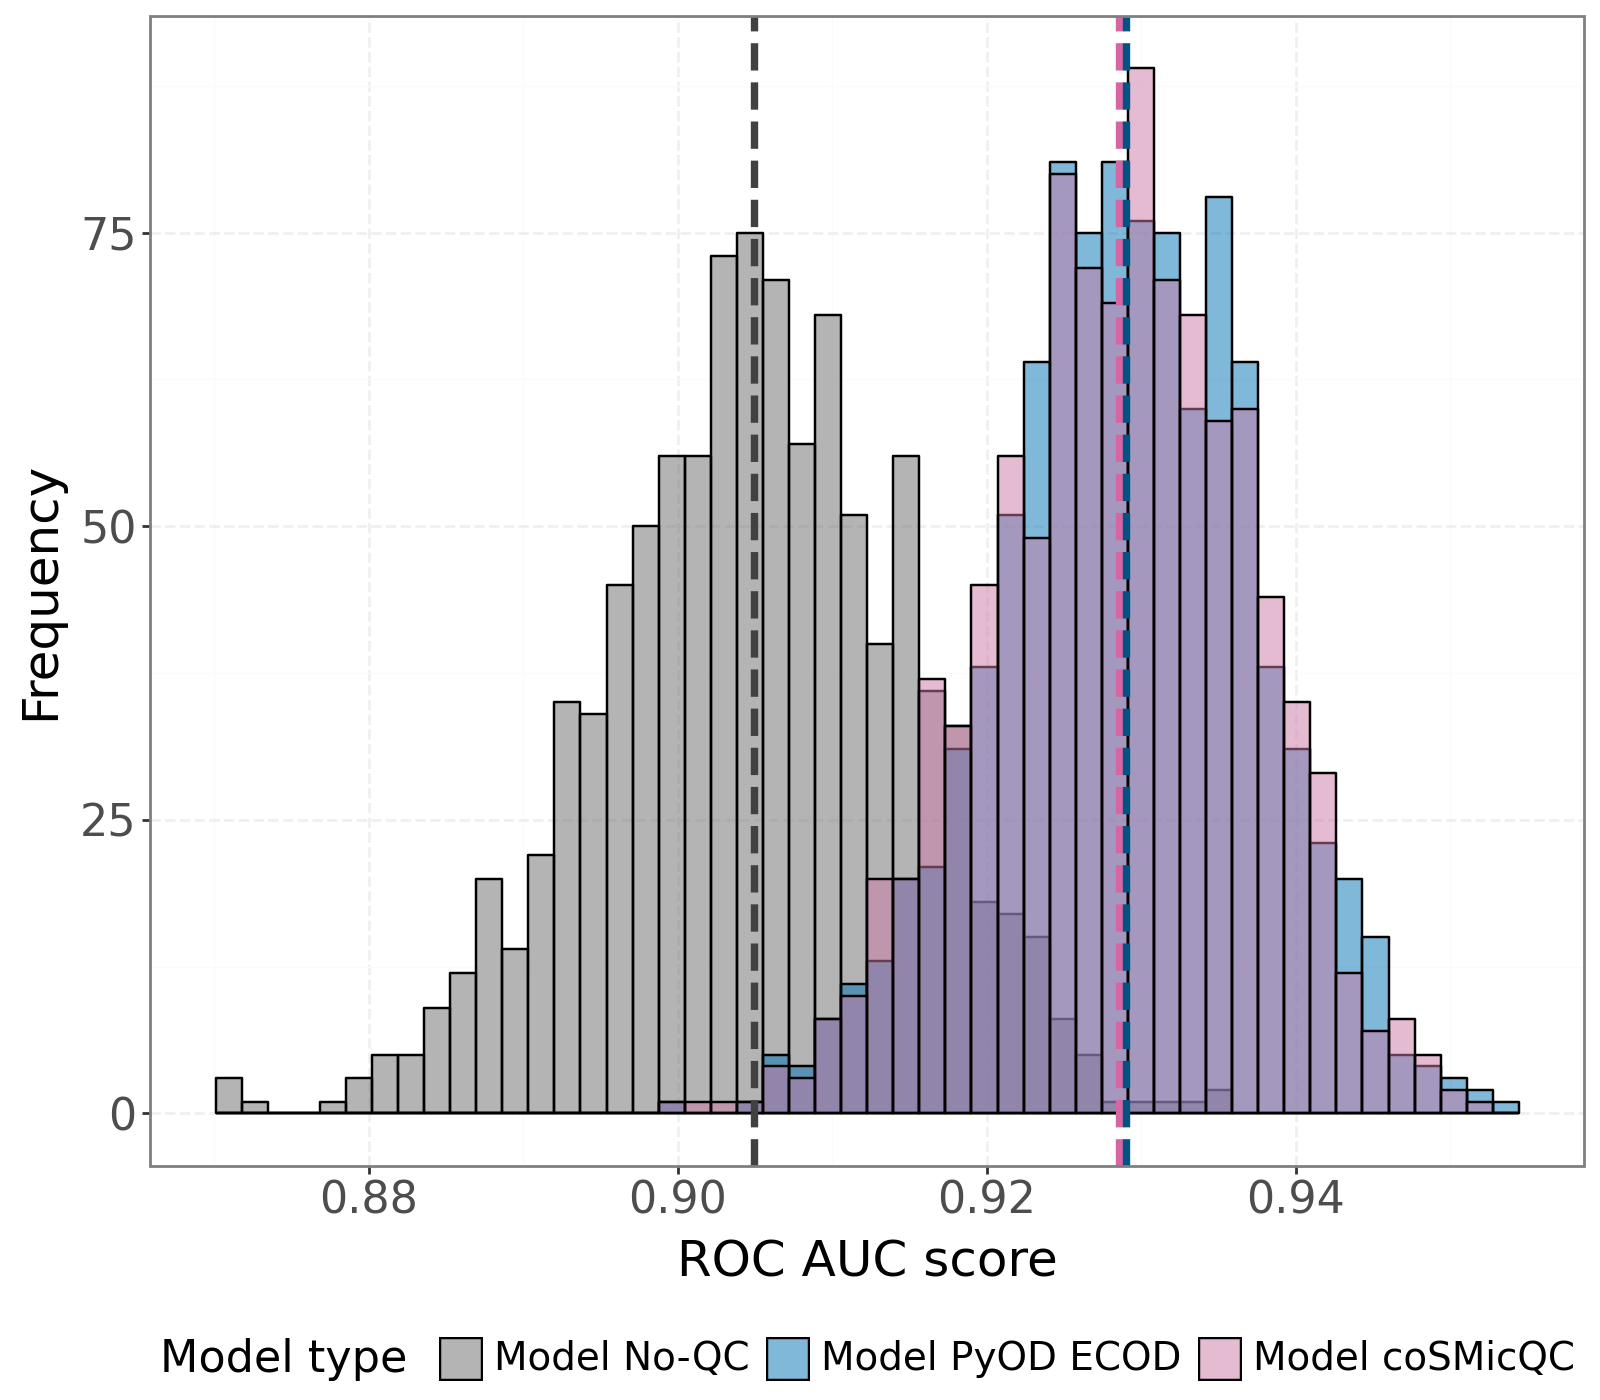

In [11]:
# Prepare the data
df_model1 = pd.DataFrame({"score": scores_model1, "model": "Model No-QC"})
df_model2 = pd.DataFrame({"score": scores_model2, "model": "Model coSMicQC"})
df_model3 = pd.DataFrame({"score": scores_model3, "model": "Model PyOD ECOD"})
df_all = pd.concat([df_model1, df_model2, df_model3])

# Set the figure size
height = 7
width = 8
set_option("figure_size", (width, height))

# Create the plot
p = (
    ggplot(df_all, aes(x="score", fill="model"))
    + geom_histogram(bins=50, alpha=0.5, position="identity", color="black")
    + geom_vline(
        xintercept=[np.mean(scores_model1), np.mean(scores_model2), np.mean(scores_model3)],
        linetype="dashed",
        size=1.5,
        color=["#414141", "#D666A3", "#005383"],
    )
    + scale_fill_manual(values={"Model No-QC": "#6B6B6B", "Model coSMicQC": "#CC79A7", "Model PyOD ECOD": "#0072B2"})
    + labs(
        x="ROC AUC score",
        y="Frequency",
        fill="Model type",
    )
    + theme_bw()
    + theme(
        legend_position="bottom",
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
        axis_title=element_text(size=18),
        axis_text=element_text(size=16),
        panel_grid_major=element_line(linetype="--", alpha=0.6),
    )
)

# Save and show
p.save(f"{figure_path}/bootstrap_ROC_AUC_QC_versus_no_QC.png", dpi=600)
p.show()
